# Wine Dataset: LDA + SVM Analysis
Replicating the cancer gene notebook pipeline on sklearn's Wine dataset.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
# Load dataset
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['WineClass'] = wine.target_names[wine.target]
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,WineClass
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
# Extract features and labels
X = wine_df.drop(columns=['WineClass'])
y = wine_df['WineClass']

print("Shape:", X.shape)
print("Unique classes:", np.unique(y))

Shape: (178, 13)
Unique classes: ['class_0' 'class_1' 'class_2']


In [4]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [5]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## CASE A: Without LDA

In [6]:
# Train SVM on all 13 features
svm_original = SVC(kernel='rbf', random_state=42)
svm_original.fit(X_train_scaled, y_train)
y_pred_original = svm_original.predict(X_test_scaled)
accuracy_original = accuracy_score(y_test, y_pred_original)

print("Accuracy WITHOUT LDA:", accuracy_original)

Accuracy WITHOUT LDA: 0.9814814814814815


In [7]:
# Compute variance before LDA
variance_before = np.var(X_train_scaled, axis=0)
total_variance_before = np.sum(variance_before)

print("Number of original features:", X_train_scaled.shape[1])
print("Average variance BEFORE LDA:", np.mean(variance_before))
print("Total variance BEFORE LDA:", total_variance_before)

Number of original features: 13
Average variance BEFORE LDA: 1.0
Total variance BEFORE LDA: 13.0


Shape after PCA: (124, 2)


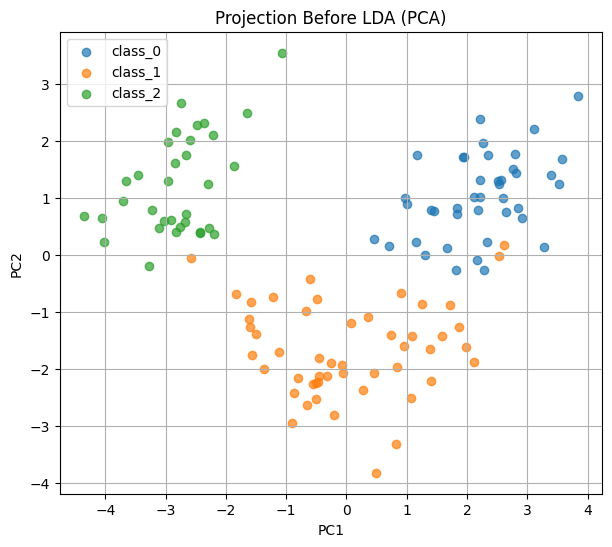

In [8]:
# Apply PCA before LDA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
print("Shape after PCA:", X_train_pca.shape)

# Scatter plot before LDA (PCA projection)
plt.figure(figsize=(7, 6))
for cls in np.unique(y_train):
    mask = y_train == cls
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=cls, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection Before LDA (PCA)")
plt.legend()
plt.grid(True)
plt.show()

## CASE B: With LDA

In [9]:
# Apply LDA for 3 classes
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda  = lda.transform(X_test_scaled)

print("Shape after LDA:", X_train_lda.shape)

Shape after LDA: (124, 2)


In [10]:
# Train SVM on LDA-reduced data
svm_lda = SVC(kernel='rbf', random_state=42)
svm_lda.fit(X_train_lda, y_train)
y_pred_lda = svm_lda.predict(X_test_lda)
accuracy_lda = accuracy_score(y_test, y_pred_lda)

print("Accuracy WITH LDA:", accuracy_lda)

Accuracy WITH LDA: 0.9629629629629629


In [11]:
# Compute variance after LDA
variance_after = np.var(X_train_lda, axis=0)
total_variance_after = np.sum(variance_after)

print("Variance per LDA component:", variance_after)
print("Total variance AFTER LDA:", total_variance_after)

Variance per LDA component: [10.66803704  5.81623159]
Total variance AFTER LDA: 16.484268632928746


In [12]:
# Compute between-class variance ratio
print("Explained discriminative variance ratio:", lda.explained_variance_ratio_)

Explained discriminative variance ratio: [0.6669277 0.3330723]


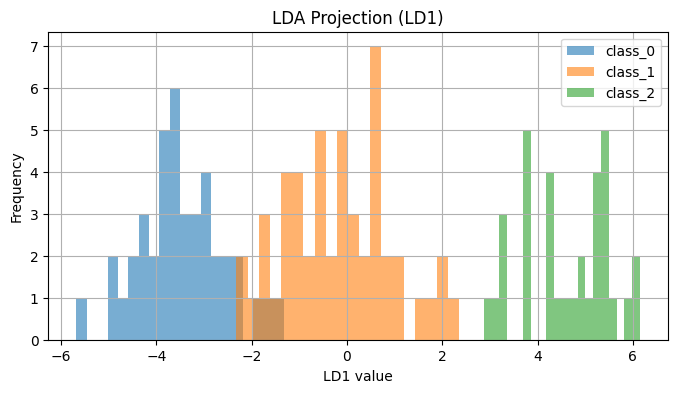

In [20]:
plt.figure(figsize=(8, 4))

classes = np.unique(y_train)

for c in classes:
    values = X_train_lda[y_train == c, 0]
    plt.hist(values, bins=20, alpha=0.6, label=c)

plt.title("LDA Projection (LD1)") # Set the title of the plot
plt.xlabel("LD1 value") # Label for the x-axis
plt.ylabel("Frequency") # Label for the y-axis
plt.legend() # Display the legend (showing class labels)
plt.grid(True) # Add a grid to the plot for better readability
plt.show() # Display the plot

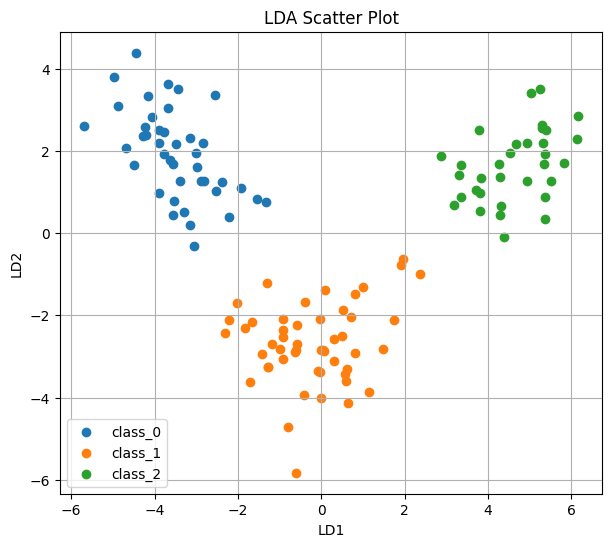

In [19]:
plt.figure(figsize=(7, 6))

classes = np.unique(y_train)

for c in classes:
    x = X_train_lda[y_train == c, 0]
    y = X_train_lda[y_train == c, 1]
    plt.scatter(x, y, label=c)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Scatter Plot")
plt.legend()
plt.grid(True)
plt.show()

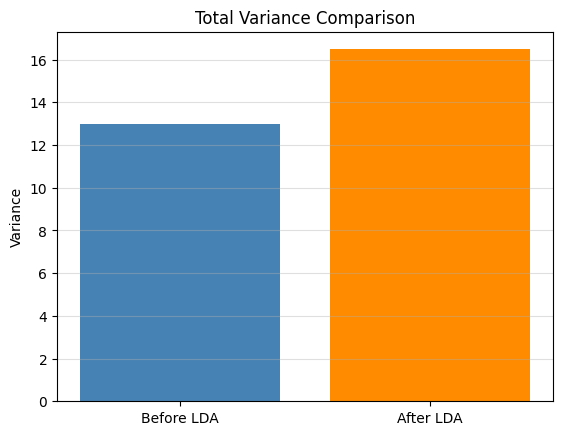

In [15]:
# Plot variance comparison
plt.bar(["Before LDA", "After LDA"],
        [total_variance_before, total_variance_after],
        color=["steelblue", "darkorange"])
plt.title("Total Variance Comparison")
plt.ylabel("Variance")
plt.grid(axis='y', alpha=0.4)
plt.show()

In [16]:
# Compare results
print("\n========== FINAL COMPARISON ==========")

print("\n--- Accuracy Comparison ---")
print("Accuracy without LDA:", accuracy_original)
print("Accuracy with    LDA:", accuracy_lda)

print("\n--- Dimensionality ---")
print("Number of features before LDA:", X_train_scaled.shape[1])
print("Number of features after  LDA:", X_train_lda.shape[1])

print("\n--- Variance Comparison ---")
print("Total variance BEFORE LDA:", total_variance_before)
print("Total variance AFTER  LDA:", total_variance_after)

print("\n--- LDA Explained Variance Ratio ---")
print("Explained variance ratio:", lda.explained_variance_ratio_)


========== FINAL COMPARISON ==========

--- Accuracy Comparison ---
Accuracy without LDA: 0.9814814814814815
Accuracy with    LDA: 0.9629629629629629

--- Dimensionality ---
Number of features before LDA: 13
Number of features after  LDA: 2

--- Variance Comparison ---
Total variance BEFORE LDA: 13.0
Total variance AFTER  LDA: 16.484268632928746

--- LDA Explained Variance Ratio ---
Explained variance ratio: [0.6669277 0.3330723]
